In [12]:
import ToyMaker as tmkr
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [13]:
def k_r():
    return 2

def gamma_r():
    return 1/10

species = {
            't':    0., 
            'cell': 0,
            'size': tmkr.birth_size(),
            'Xr': 0.,
}
reactions = {

    k_r: {'create': ['Xr']},
    gamma_r:{'destroy': ['Xr']},
    'division': {'dilute': ['Xr']}

}

tmax = 500
sampling_time = 1
cell = 1
cells = 3000
sim = tmkr.Simulate_Division(species, reactions, tmax, sampling_time, cell, doubling_time=18.)
# [print(sim[i]) for i in range(len(sim))];

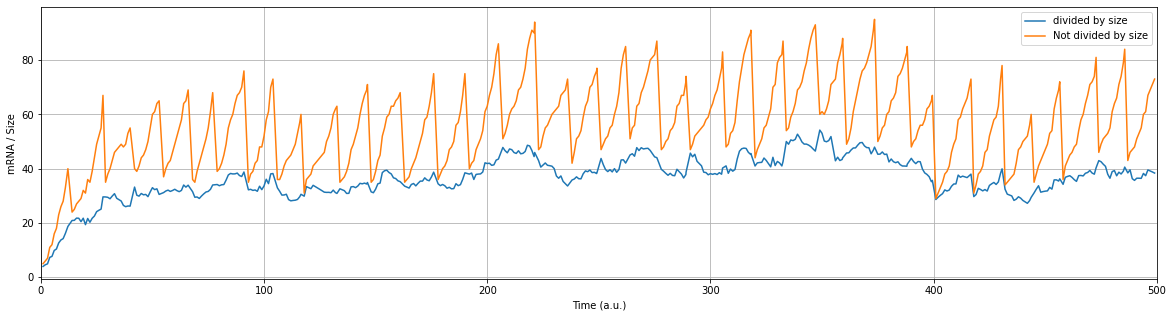

In [14]:
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0],sim[:,3]/sim[:,2], label='divided by size')
plt.plot(sim[:,0],sim[:,3], label='Not divided by size')
plt.xlim(0, tmax)
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.grid(True)
plt.legend(loc='best')

Text(0, 0.5, 'Size')

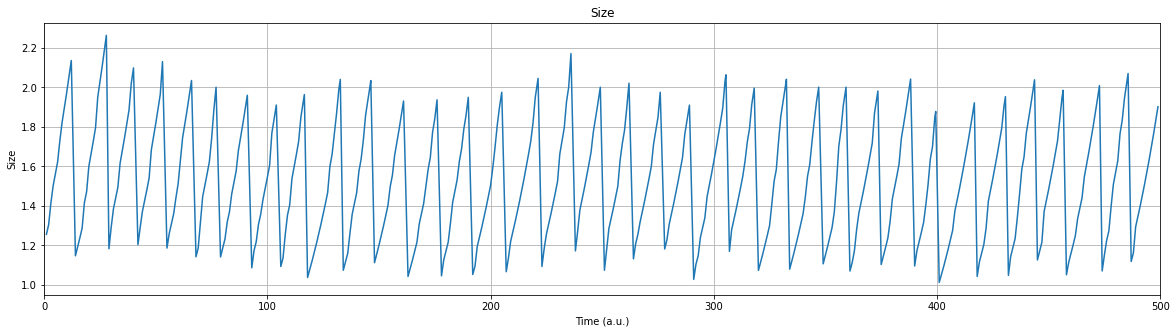

In [15]:
size = [sim[i][2] for i in range(len(sim))]
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0],size)
plt.title('Size')
plt.grid(True)
plt.xlim(0, tmax)
# plt.ylim(1.8, 2.3)
plt.xlabel('Time (a.u.)')
plt.ylabel('Size')

In [16]:
sims = [tmkr.Simulate_Division(species, reactions, tmax, sampling_time, c) for c in tqdm(range(cells))]

100%|██████████| 3000/3000 [01:11<00:00, 41.89it/s]


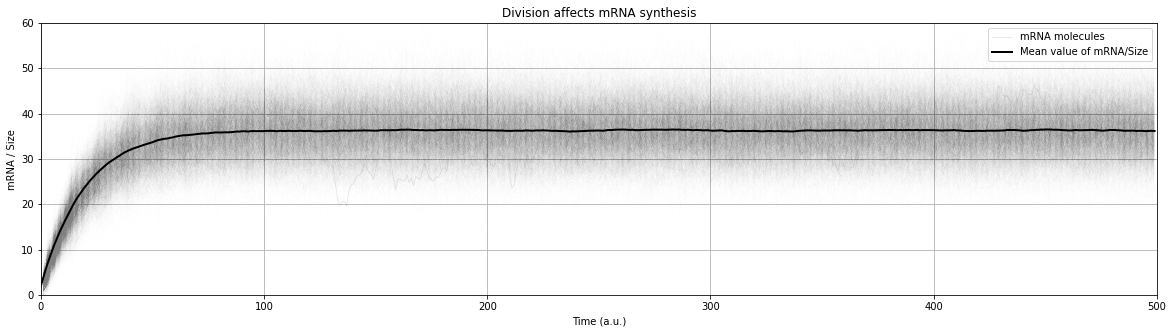

In [17]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mean_mrna = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2)

[plt.plot(time_arr[c], rna_arr[c]/size_arr[c], lw=0.01, color='grey', alpha=0.2) for c in range(cells)];
plt.plot(time_arr[0], rna_arr[0]/size_arr[0], lw=0.8, color='grey', label='mRNA molecules', alpha=0.2)
plt.plot(mean_mrna, color='black', lw=2,label='Mean value of mRNA/Size')
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.xlim(0, tmax)
plt.ylim(0, 60)
# plt.hlines((k_r()/gamma_r()), 0, tmax, color='red', label='Theoretical mRNA levels at steady state')
plt.title('Division affects mRNA synthesis')
plt.legend(loc='upper right')
plt.grid(True)

(0.0, 500.0)

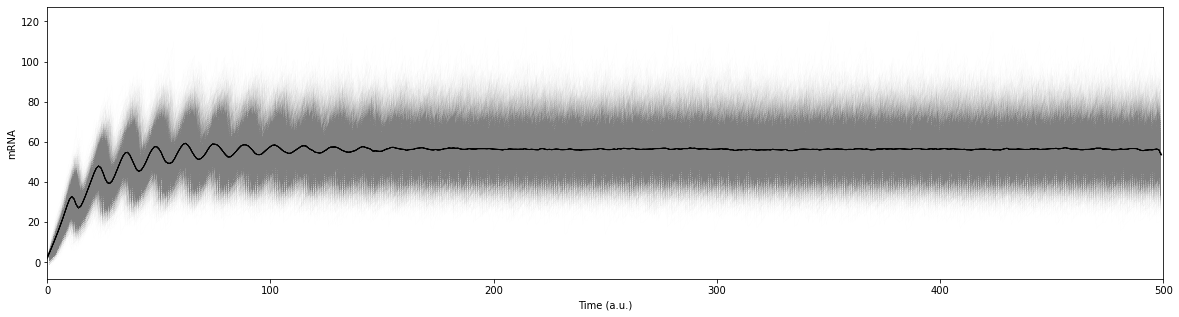

In [18]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mean_mrna = tmkr.get_mean_per_cell(cells=sims, samples=cells, tmax=tmax, species_idx=3)
plt.plot(mean_mrna, color='black', lw=2,label='Mean value of mRNA/Size')
[plt.plot(time_arr[c], rna_arr[c], lw=0.05, color='grey', alpha=0.1) for c in range(cells)];
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA')
plt.xlim(0, tmax)
# plt.hlines((k_r()/gamma_r()), 0, tmax, color='red')

### Steady State

In [19]:
mu = np.log(2)/18.
ss_d = (k_r() - mu)/gamma_r()
ss_d

19.61491823302225

In [20]:
ss = k_r() / (np.log(2)/18)
ss

51.937021472002684

In [21]:
ss = k_r()/gamma_r()
ss

20.0